In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys
import glob
from pathlib import Path

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm 
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp001/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/beads3um/20260416/beads_tracks.csv


/Users/sasakinozomu/code/MTCargo_analysis/libs/fit_model.py:8: RuntimeWarning: invalid value encountered in log10
  return k * x + np.log10(a)


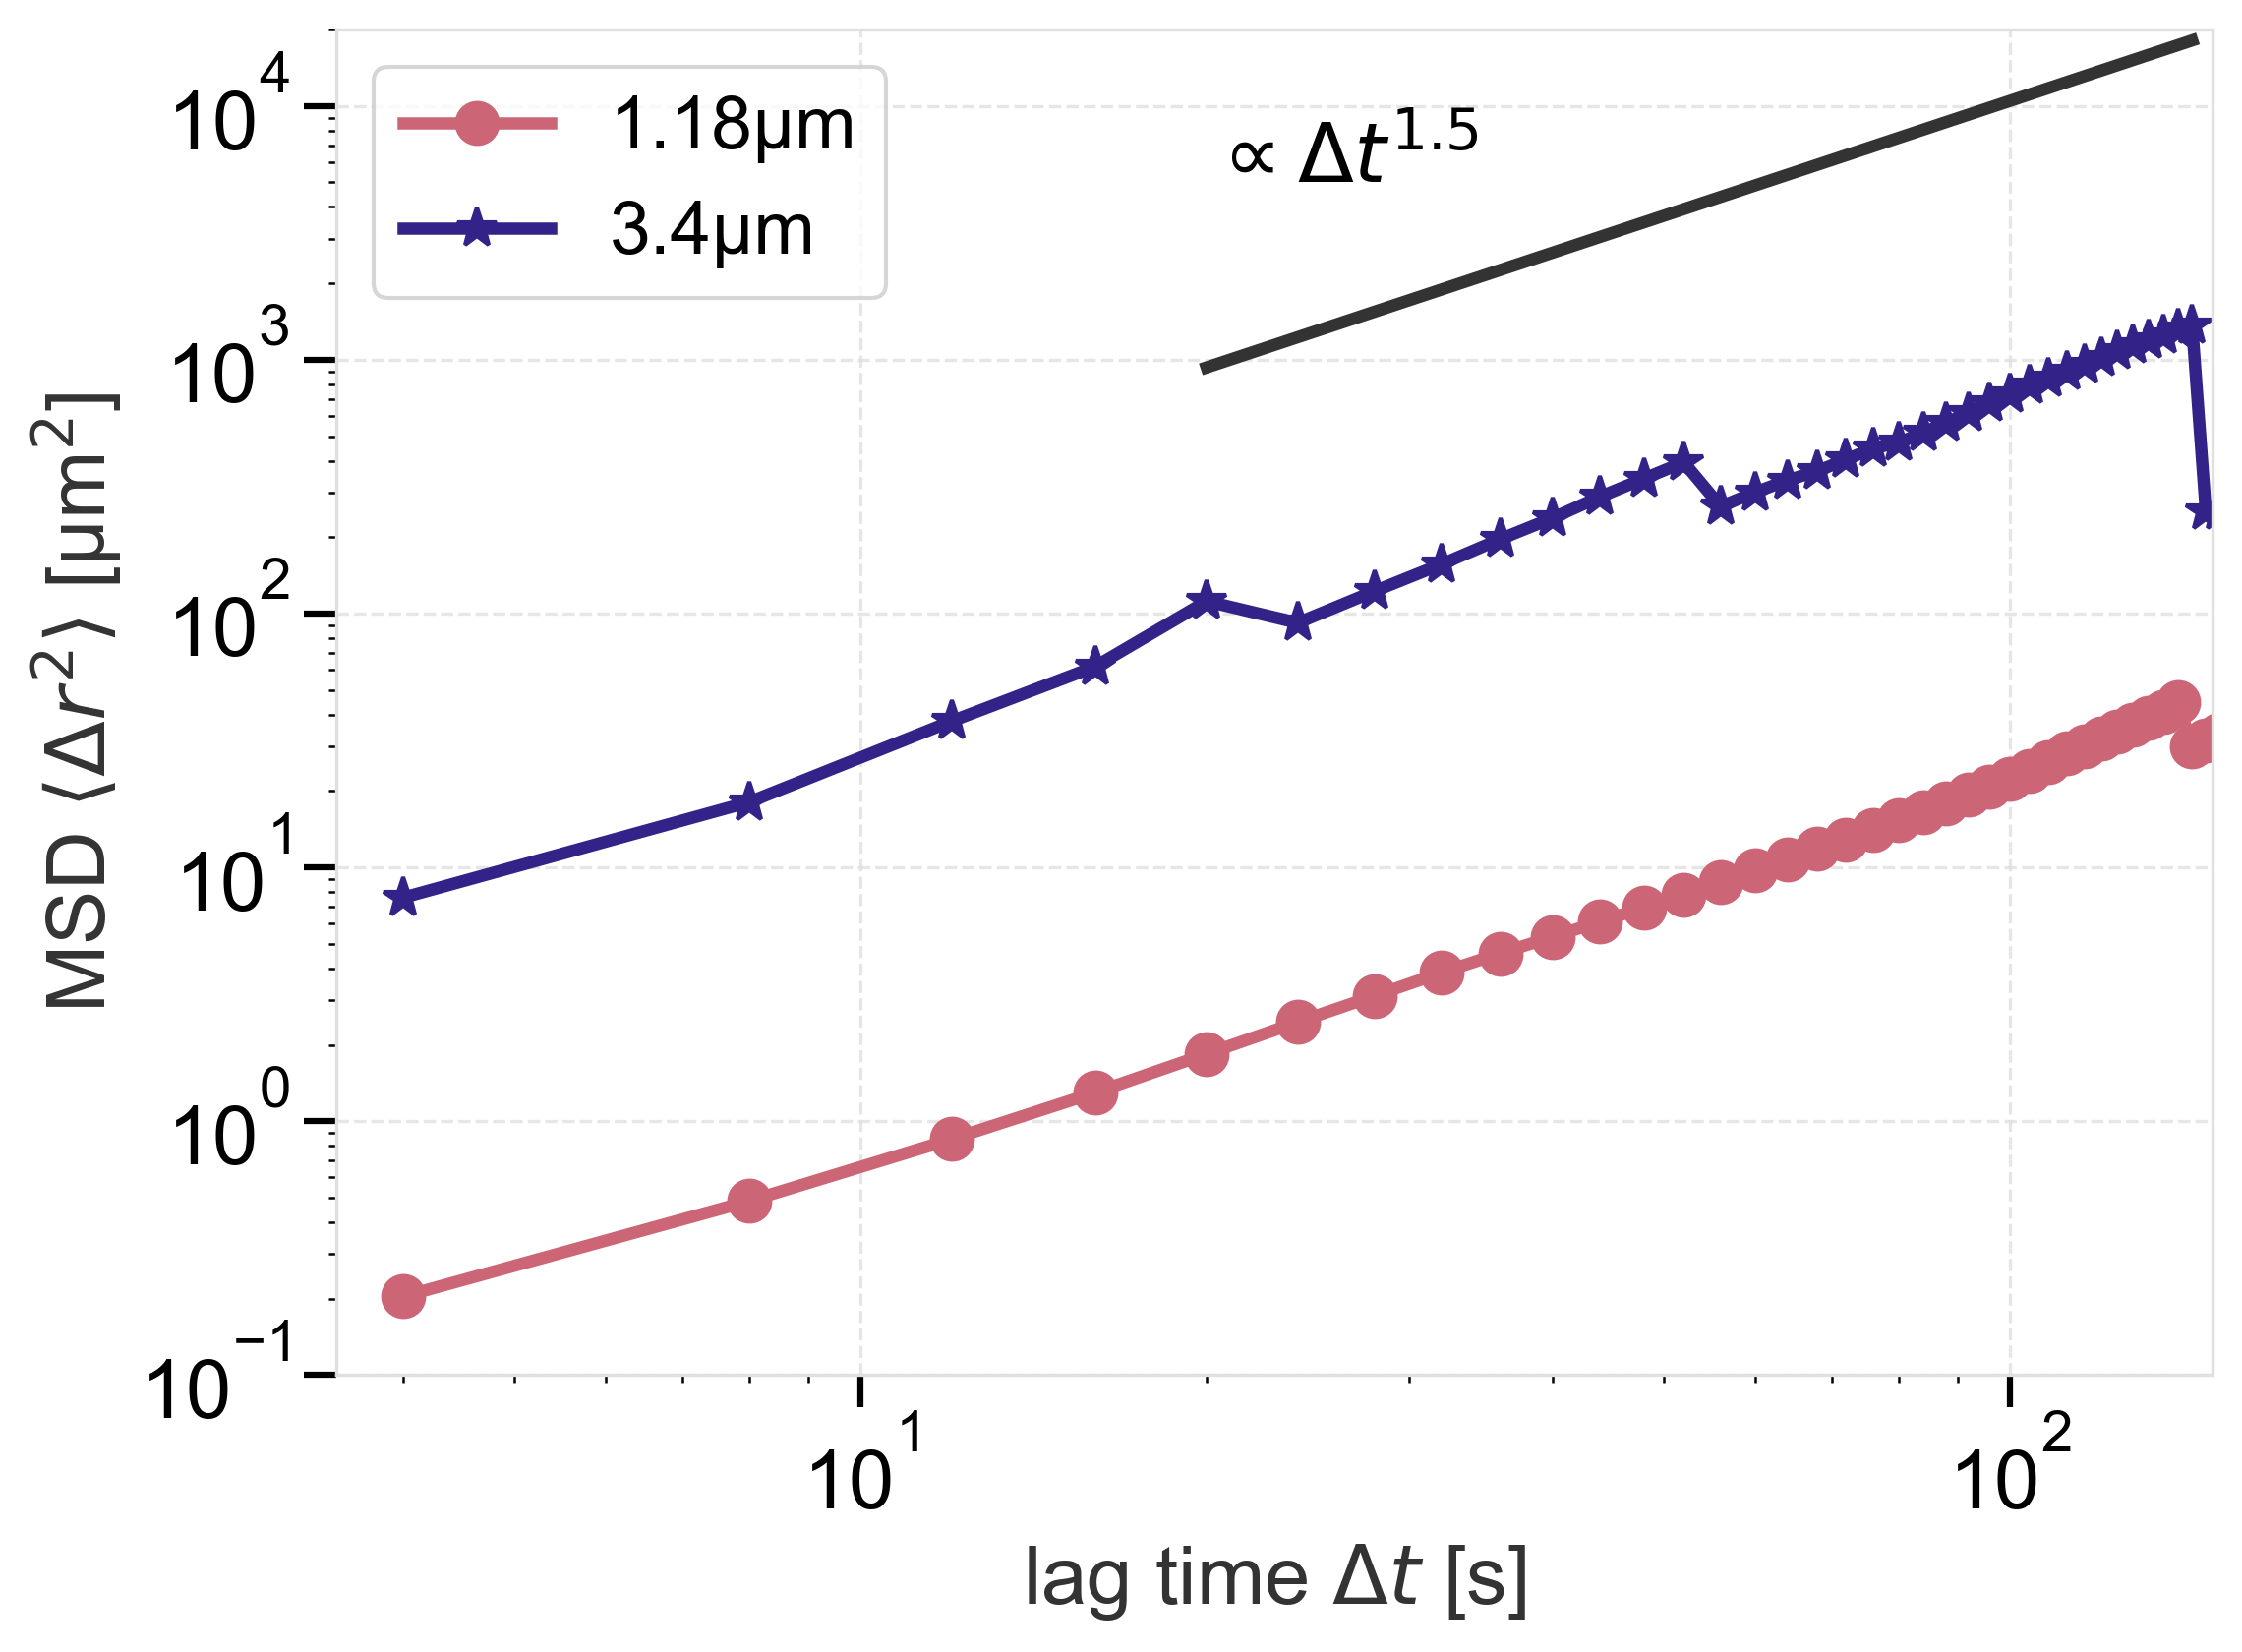

In [ ]:
mypass = '/mnt/NAS-Ebanaru/sasaki/MTSingleBeads'
#mypass = '/Volumes/My Passport/Sasaki/MTsingleBeads'

path0 = os.path.join(mypass,"20260121/beads_trans_crop_crop/beads_tracks.csv")
path1 = os.path.join(mypass,"20260121/exp_crop1/beads_tracks.csv")
path2 = os.path.join(mypass,"20260122/exp/beads_tracks.csv")
path3 = os.path.join(mypass,"20260122/exp001/beads_tracks.csv")

path3um = os.path.join(mypass,"beads3um/20260603/beads_tracks.csv")
#path4 = os.path.join(mypass,"20260122/exp002/beads_tracks.csv")


def concatMSD(path_list, interval_list, scale = 0.11):
    IMSD_list = []
    for i in range(len(path_list)):
        print(path_list[i])
        IMSD, _ = dpm.get_msd(path_list[i], scale, interval_list[i], threshold = 0.0)
        IMSD['particle'] += 10000*i
        IMSD_list.append(IMSD)

    return pd.concat(IMSD_list)

I_concat_1um = concatMSD([path0, path1, path2, path3], [ 4, 4, 4, 4])
I_concat_3um = concatMSD([path3um], [ 4])

scale = 0.11

min_t = 20
max_t = 144

minimum=min_t/4
maximum=max_t/4

emsd_combined_1um, emsd_err_combined_1um = dpm.get_emsd_err(I_concat_1um)
emsd_combined_3um, emsd_err_combined_3um = dpm.get_emsd_err(I_concat_3um)

mask = (emsd_combined_1um.index > minimum) & (emsd_combined_1um.index < maximum)

# take log10 of selected x and y values and convert to numpy arrays
x = np.log10(emsd_combined_1um.index[mask].to_numpy())
y = np.log10(np.float32(emsd_combined_1um['MSD'][mask].to_numpy()))
 # remove non-finite entries (e.g., log of non-positive values)
finite = np.isfinite(x) & np.isfinite(y)
x = x[finite]
y = y[finite]
# fit
popt, pcov = curve_fit(fm.ln_pl, x, y)

fig, ax = plt.subplots()

#ax.plot(I_concat_1um['lag time'], I_concat_1um['MSD'], color='#333333', alpha =0.1, lw=1, label='Independent particle')

ax.plot(emsd_combined_1um.index, emsd_combined_1um['MSD'], marker='o', label='1.18\u03bcm')
ax.plot(emsd_combined_3um.index, emsd_combined_3um['MSD'], marker='*', label='3.4\u03bcm')

"""ax.fill_between(emsd_combined.index,
                emsd_combined['MSD'] - emsd_err_combined,
                emsd_combined['MSD'] + emsd_err_combined,
                alpha=0.2)
"""

ax.legend()

xrange = [min_t, max_t]

ax.plot(xrange, 100*fm.power_law(xrange, *popt) * 5, label = f'{popt[1]:.2f}$\\times\\Delta t^{{{popt[0]:.2f}}}$', color='#333333')
ax.text(20, 5e3, f'$\propto \Delta t^{{{popt[0]:.1f}}}$')


ax.set(
    xlim=(3.5e-0, 150),
    ylim=(1e-1, 2e4),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta t$ [s]',
    ylabel='MSD $\\langle \\Delta r^2 \\rangle$ [\u03bcm$^2$]'
    )

cd = os.getcwd()
fig.savefig(f"{cd}/figures/MSD.png", bbox_inches = 'tight')
fig.savefig(f"{cd}/figures/MSD.pdf", bbox_inches = 'tight')


/mnt/e/Sasaki/MTSingleBeads/20260121/beads_trans_crop_crop/beads_tracks.csv
/mnt/e/Sasaki/MTSingleBeads/20260121/exp_crop1/beads_tracks.csv
/mnt/e/Sasaki/MTSingleBeads/20260122/exp/beads_tracks.csv
/mnt/e/Sasaki/MTSingleBeads/20260122/exp001/beads_tracks.csv


/home/sasaki/MTCargo_analysis/libs/fit_model.py:8: RuntimeWarning: invalid value encountered in log10
  return k * x + np.log10(a)


'\ncd = os.getcwd()\nfig.savefig(f"{cd}/figures/MSD.png", bbox_inches = \'tight\')\nfig.savefig(f"{cd}/figures/MSD.pdf", bbox_inches = \'tight\')\n'

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following famil

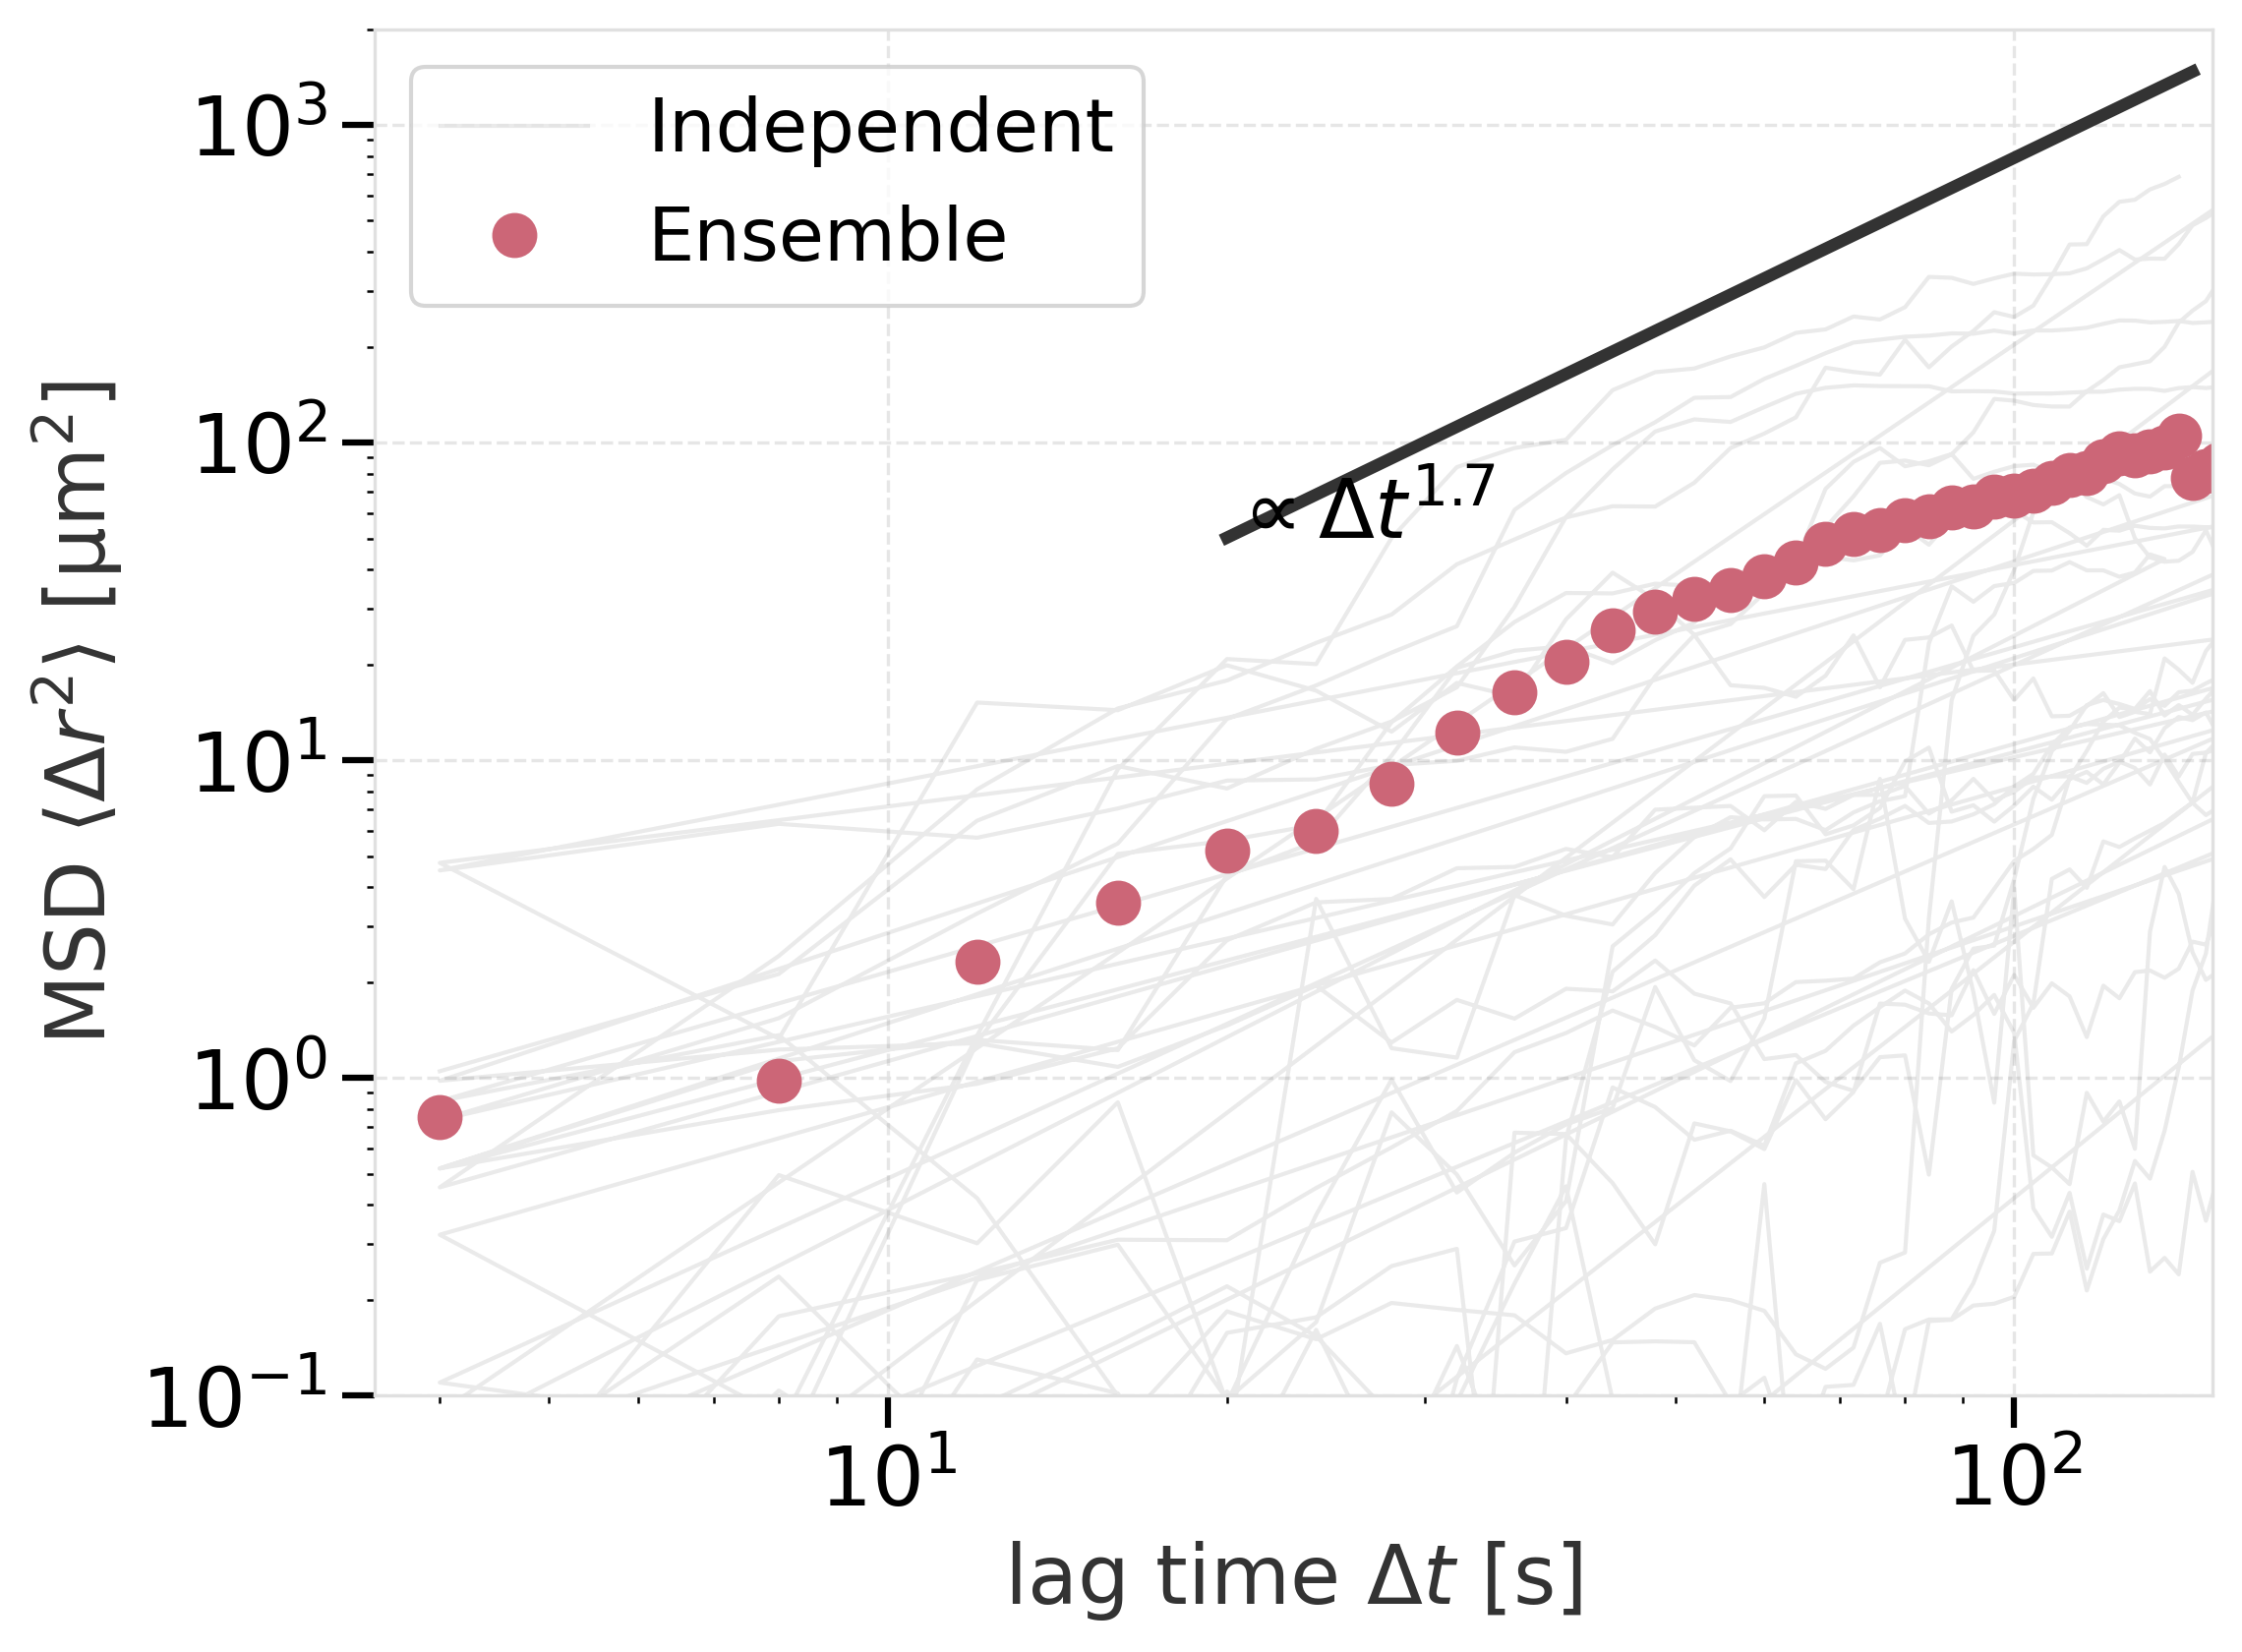

In [3]:
mypass = '/mnt/e/Sasaki/MTSingleBeads'
#mypass = '/Volumes/My Passport/Sasaki/MTsingleBeads'

path0 = os.path.join(mypass,"20260121/beads_trans_crop_crop/beads_tracks.csv")
path1 = os.path.join(mypass,"20260121/exp_crop1/beads_tracks.csv")
path2 = os.path.join(mypass,"20260122/exp/beads_tracks.csv")
path3 = os.path.join(mypass,"20260122/exp001/beads_tracks.csv")
#path4 = os.path.join(mypass,"20260122/exp002/beads_tracks.csv")


def concatMSD(path_list, interval_list, scale = 0.11, time_averaged = True):
    IMSD_list = []
    for i in range(len(path_list)):
        print(path_list[i])
        IMSD, _ = dpm.get_msd(path_list[i], scale, interval_list[i], threshold = 0.0, time_averaged=time_averaged)
        IMSD['particle'] += 10000*i
        IMSD_list.append(IMSD)

    return pd.concat(IMSD_list)

I_concat = concatMSD([path0, path1, path2, path3], [ 4, 4, 4, 4], time_averaged=False)

scale = 0.11

min_t = 20
max_t = 144

minimum=min_t/4
maximum=max_t/4

emsd_combined, emsd_err_combined = dpm.get_emsd_err(I_concat)

mask = (emsd_combined.index > minimum) & (emsd_combined.index < maximum)

# take log10 of selected x and y values and convert to numpy arrays
x = np.log10(emsd_combined.index[mask].to_numpy())
y = np.log10(np.float32(emsd_combined['MSD'][mask].to_numpy()))
 # remove non-finite entries (e.g., log of non-positive values)
finite = np.isfinite(x) & np.isfinite(y)
x = x[finite]
y = y[finite]
# fit
popt, pcov = curve_fit(fm.ln_pl, x, y)

fig, ax = plt.subplots()

ax.plot(I_concat['lag time'], I_concat['MSD'], color='#333333', alpha =0.1, lw=1, label='Independent')

#ax.plot(TA_emsd_combined.index, TA_emsd_combined['MSD'], linestyle = 'None', marker='o', label='Time Averaged', color = style_colors[0])
ax.plot(emsd_combined.index, emsd_combined['MSD'], linestyle = 'None', marker='o', label='Ensemble')

"""
ax.fill_between(emsd_combined.index,
                emsd_combined['MSD'] - emsd_err_combined,
                emsd_combined['MSD'] + emsd_err_combined,
                alpha=0.2)
"""

ax.legend()

xrange = [min_t, max_t]

ax.plot(xrange, fm.power_law(xrange, *popt) * 10, label = f'{popt[1]:.2f}$\\times\\Delta t^{{{popt[0]:.2f}}}$', color = '#333333')


ax.text(20, 5e1, f'$\propto \Delta t^{{{popt[0]:.1f}}}$')

ax.set(
    xlim=(3.5e-0, 150),
    ylim=(1e-1, 2e3),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta t$ [s]',
    ylabel='MSD $\\langle \\Delta r^2 \\rangle$ [\u03bcm$^2$]'
    )
"""
cd = os.getcwd()
fig.savefig(f"{cd}/figures/MSD.png", bbox_inches = 'tight')
fig.savefig(f"{cd}/figures/MSD.pdf", bbox_inches = 'tight')
"""

/mnt/NAS-Ebanaru/sasaki/MTSingleBeads/beads1um/20260122/exp001/beads_tracks.csv
/mnt/NAS-Ebanaru/sasaki/MTSingleBeads/beads1um/20260122/exp/beads_tracks.csv
/mnt/NAS-Ebanaru/sasaki/MTSingleBeads/beads1um/20260121/exp_crop1/beads_tracks.csv
/mnt/NAS-Ebanaru/sasaki/MTSingleBeads/beads1um/20260121/beads_trans_crop_crop/beads_tracks.csv
/mnt/NAS-Ebanaru/sasaki/MTSingleBeads/beads3um/20260603/beads3um003/beads_tracks.csv
/mnt/NAS-Ebanaru/sasaki/MTSingleBeads/beads3um/20260603/beads3um002/beads_tracks.csv
/mnt/NAS-Ebanaru/sasaki/MTSingleBeads/beads3um/20260603/beads3um004/beads_tracks.csv
/mnt/NAS-Ebanaru/sasaki/MTSingleBeads/beads7um/20260608/beads7um/beads_tracks.csv
/mnt/NAS-Ebanaru/sasaki/MTSingleBeads/beads7um/20260608/beads7um001/beads_tracks.csv
/mnt/NAS-Ebanaru/sasaki/MTSingleBeads/beads7um/20260608/beads7um002/beads_tracks.csv
/mnt/NAS-Ebanaru/sasaki/MTSingleBeads/beads7um/20260608/beads7um003/beads_tracks.csv
/mnt/NAS-Ebanaru/sasaki/MTSingleBeads/beads20um/20260602/beads20um/beads_

/home/sasaki/MTCargo_analysis/libs/fit_model.py:8: RuntimeWarning: invalid value encountered in log10
  return k * x + np.log10(a)


'fig.savefig(mypass / "figure" / "MSD.png", bbox_inches = \'tight\')\nfig.savefig(mypass / "figure" / "MSD.pdf", bbox_inches = \'tight\')'

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following famil

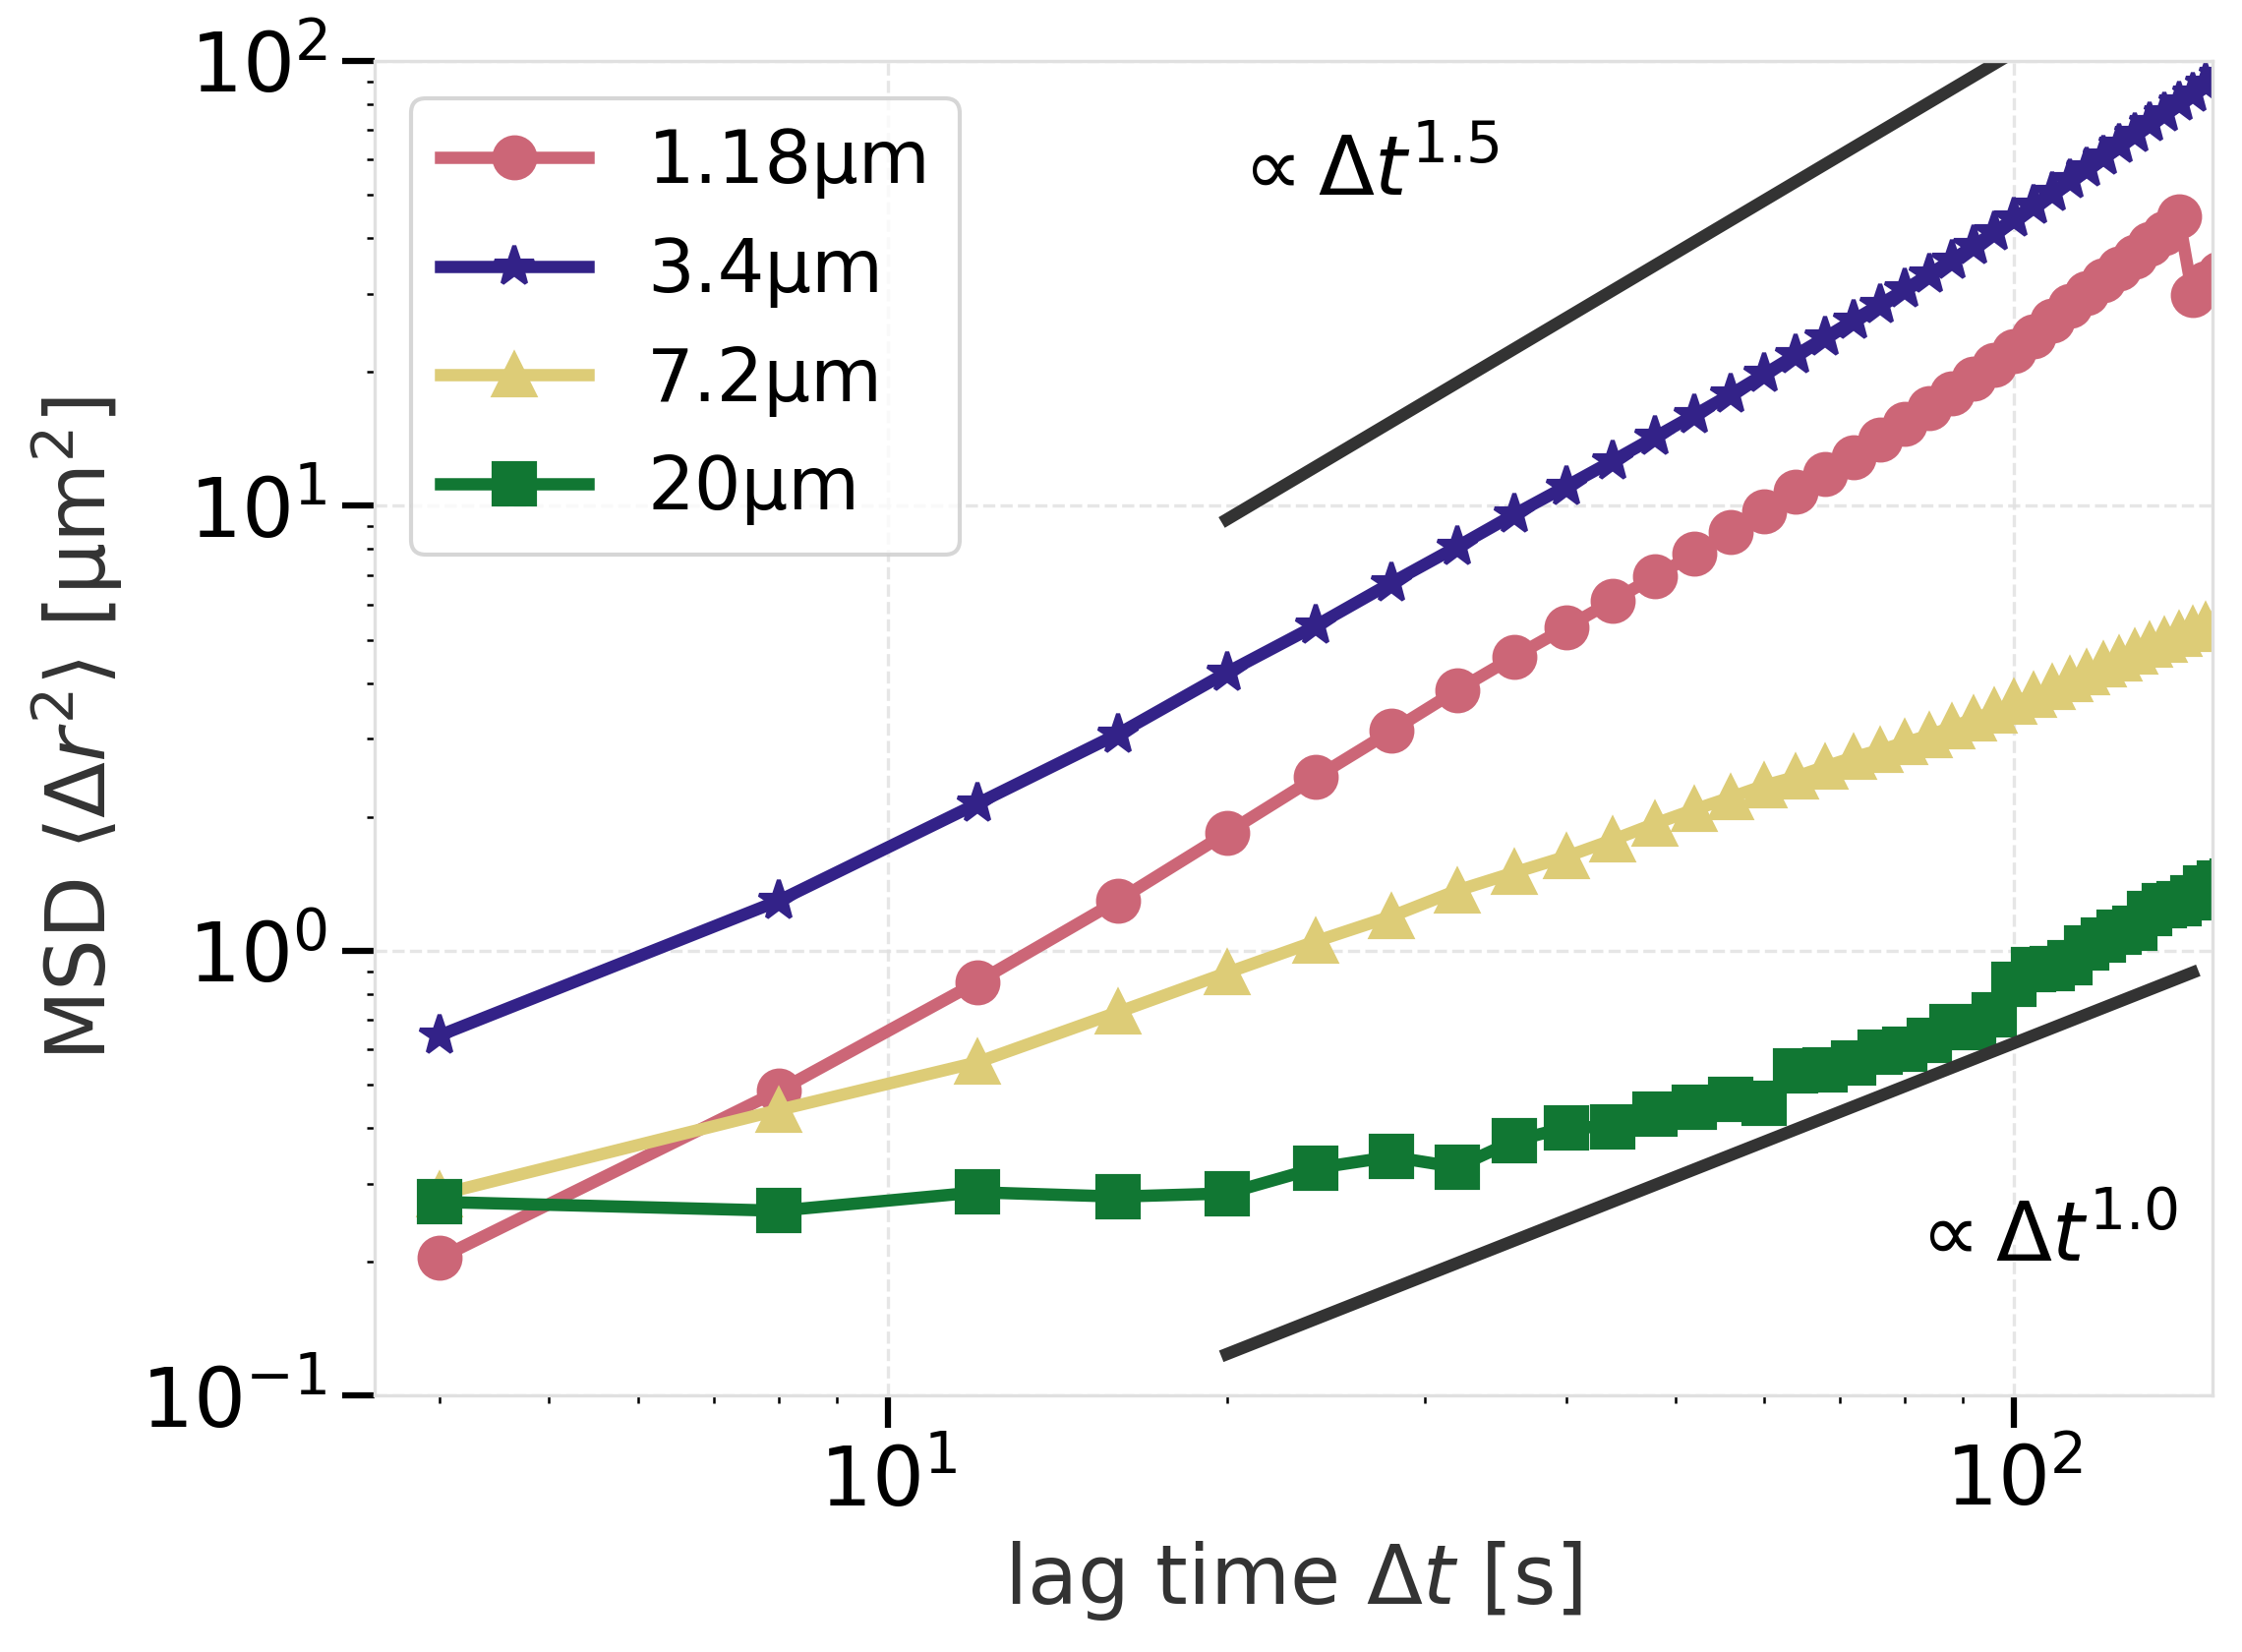

In [ ]:
mypass = Path('/mnt/NAS-Ebanaru/sasaki/MTSingleBeads')
#mypass = '/Volumes/My Passport/Sasaki/MTsingleBeads'

def concatMSD(folder, interval_list, scale = 0.11):
    IMSD_list = []
    num = 0
    for i in glob.glob(str(Path(folder) / "*" / "*" /"beads_tracks.csv")):
        print(i)
        IMSD, _ = dpm.get_msd(i, scale, interval_list[0], threshold = 0.0)
        IMSD['particle'] += 10000* num
        num += 1
        IMSD_list.append(IMSD)

    return pd.concat(IMSD_list)



I_concat_1um = concatMSD(mypass / "beads1um", [ 4, 4, 4, 4])
I_concat_3um = concatMSD(mypass / "beads3um", [4, 4, 4])
I_concat_7um = concatMSD(mypass / "beads7um", [4, 4, 4, 4])
I_concat_20um = concatMSD(mypass / "beads20um", [4, 4, 4, 4])

scale = 0.11

min_t = 20
max_t = 144

minimum=min_t/4
maximum=max_t/4

emsd_combined_1um, emsd_err_combined_1um = dpm.get_emsd_err(I_concat_1um)
emsd_combined_3um, emsd_err_combined_3um = dpm.get_emsd_err(I_concat_3um)
emsd_combined_7um, emsd_err_combined_7um = dpm.get_emsd_err(I_concat_7um)
emsd_combined_20um, emsd_err_combined_20um = dpm.get_emsd_err(I_concat_20um)

mask = (emsd_combined_1um.index > minimum) & (emsd_combined_1um.index < maximum)

# take log10 of selected x and y values and convert to numpy arrays
x = np.log10(emsd_combined_1um.index[mask].to_numpy())
y = np.log10(np.float32(emsd_combined_1um['MSD'][mask].to_numpy()))
 # remove non-finite entries (e.g., log of non-positive values)
finite = np.isfinite(x) & np.isfinite(y)
x = x[finite]
y = y[finite]
# fit
popt, pcov = curve_fit(fm.ln_pl, x, y)

fig, ax = plt.subplots()

#ax.plot(I_concat_1um['lag time'], I_concat_1um['MSD'], color='#333333', alpha =0.1, lw=1, label='Independent particle')

ax.plot(emsd_combined_1um.index, emsd_combined_1um['MSD'], marker='o', label='1.18\u03bcm')
ax.plot(emsd_combined_3um.index, emsd_combined_3um['MSD'], marker='*', label='3.34\u03bcm')
ax.plot(emsd_combined_7um.index, emsd_combined_7um['MSD'], marker='^', label='7.24\u03bcm')
ax.plot(emsd_combined_20um.index, emsd_combined_20um['MSD'], marker='s', label='20\u03bcm')

"""ax.fill_between(emsd_combined.index,
                emsd_combined['MSD'] - emsd_err_combined,
                emsd_combined['MSD'] + emsd_err_combined,
                alpha=0.2)
"""

ax.legend()

xrange = [min_t, max_t]

ax.plot(xrange, fm.power_law(xrange, *popt) * 5, label = f'{popt[1]:.2f}$\\times\\Delta t^{{{popt[0]:.2f}}}$', color='#333333')
ax.text(20, 5e1, f'$\propto \Delta t^{{{popt[0]:.1f}}}$')

ax.plot(xrange, fm.power_law(xrange, 1 ,popt[1]*1e-1) * 3, label = f'{popt[1]:.2f}$\\times\\Delta t^{{{popt[0]:.2f}}}$', color='#333333')
ax.text(80, 2e-1, f'$\propto \Delta t^{{{1.0}}}$')

ax.set(
    xlim=(3.5e-0, 150),
    ylim=(1e-1, 1e2),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta t$ [s]',
    ylabel='MSD $\\langle \\Delta r^2 \\rangle$ [\u03bcm$^2$]'
    )


"""fig.savefig(mypass / "figure" / "MSD.png", bbox_inches = 'tight')
fig.savefig(mypass / "figure" / "MSD.pdf", bbox_inches = 'tight')"""


/home/sasaki/MTCargo_analysis/libs/fit_model.py:8: RuntimeWarning: invalid value encountered in log10
  return k * x + np.log10(a)
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because n

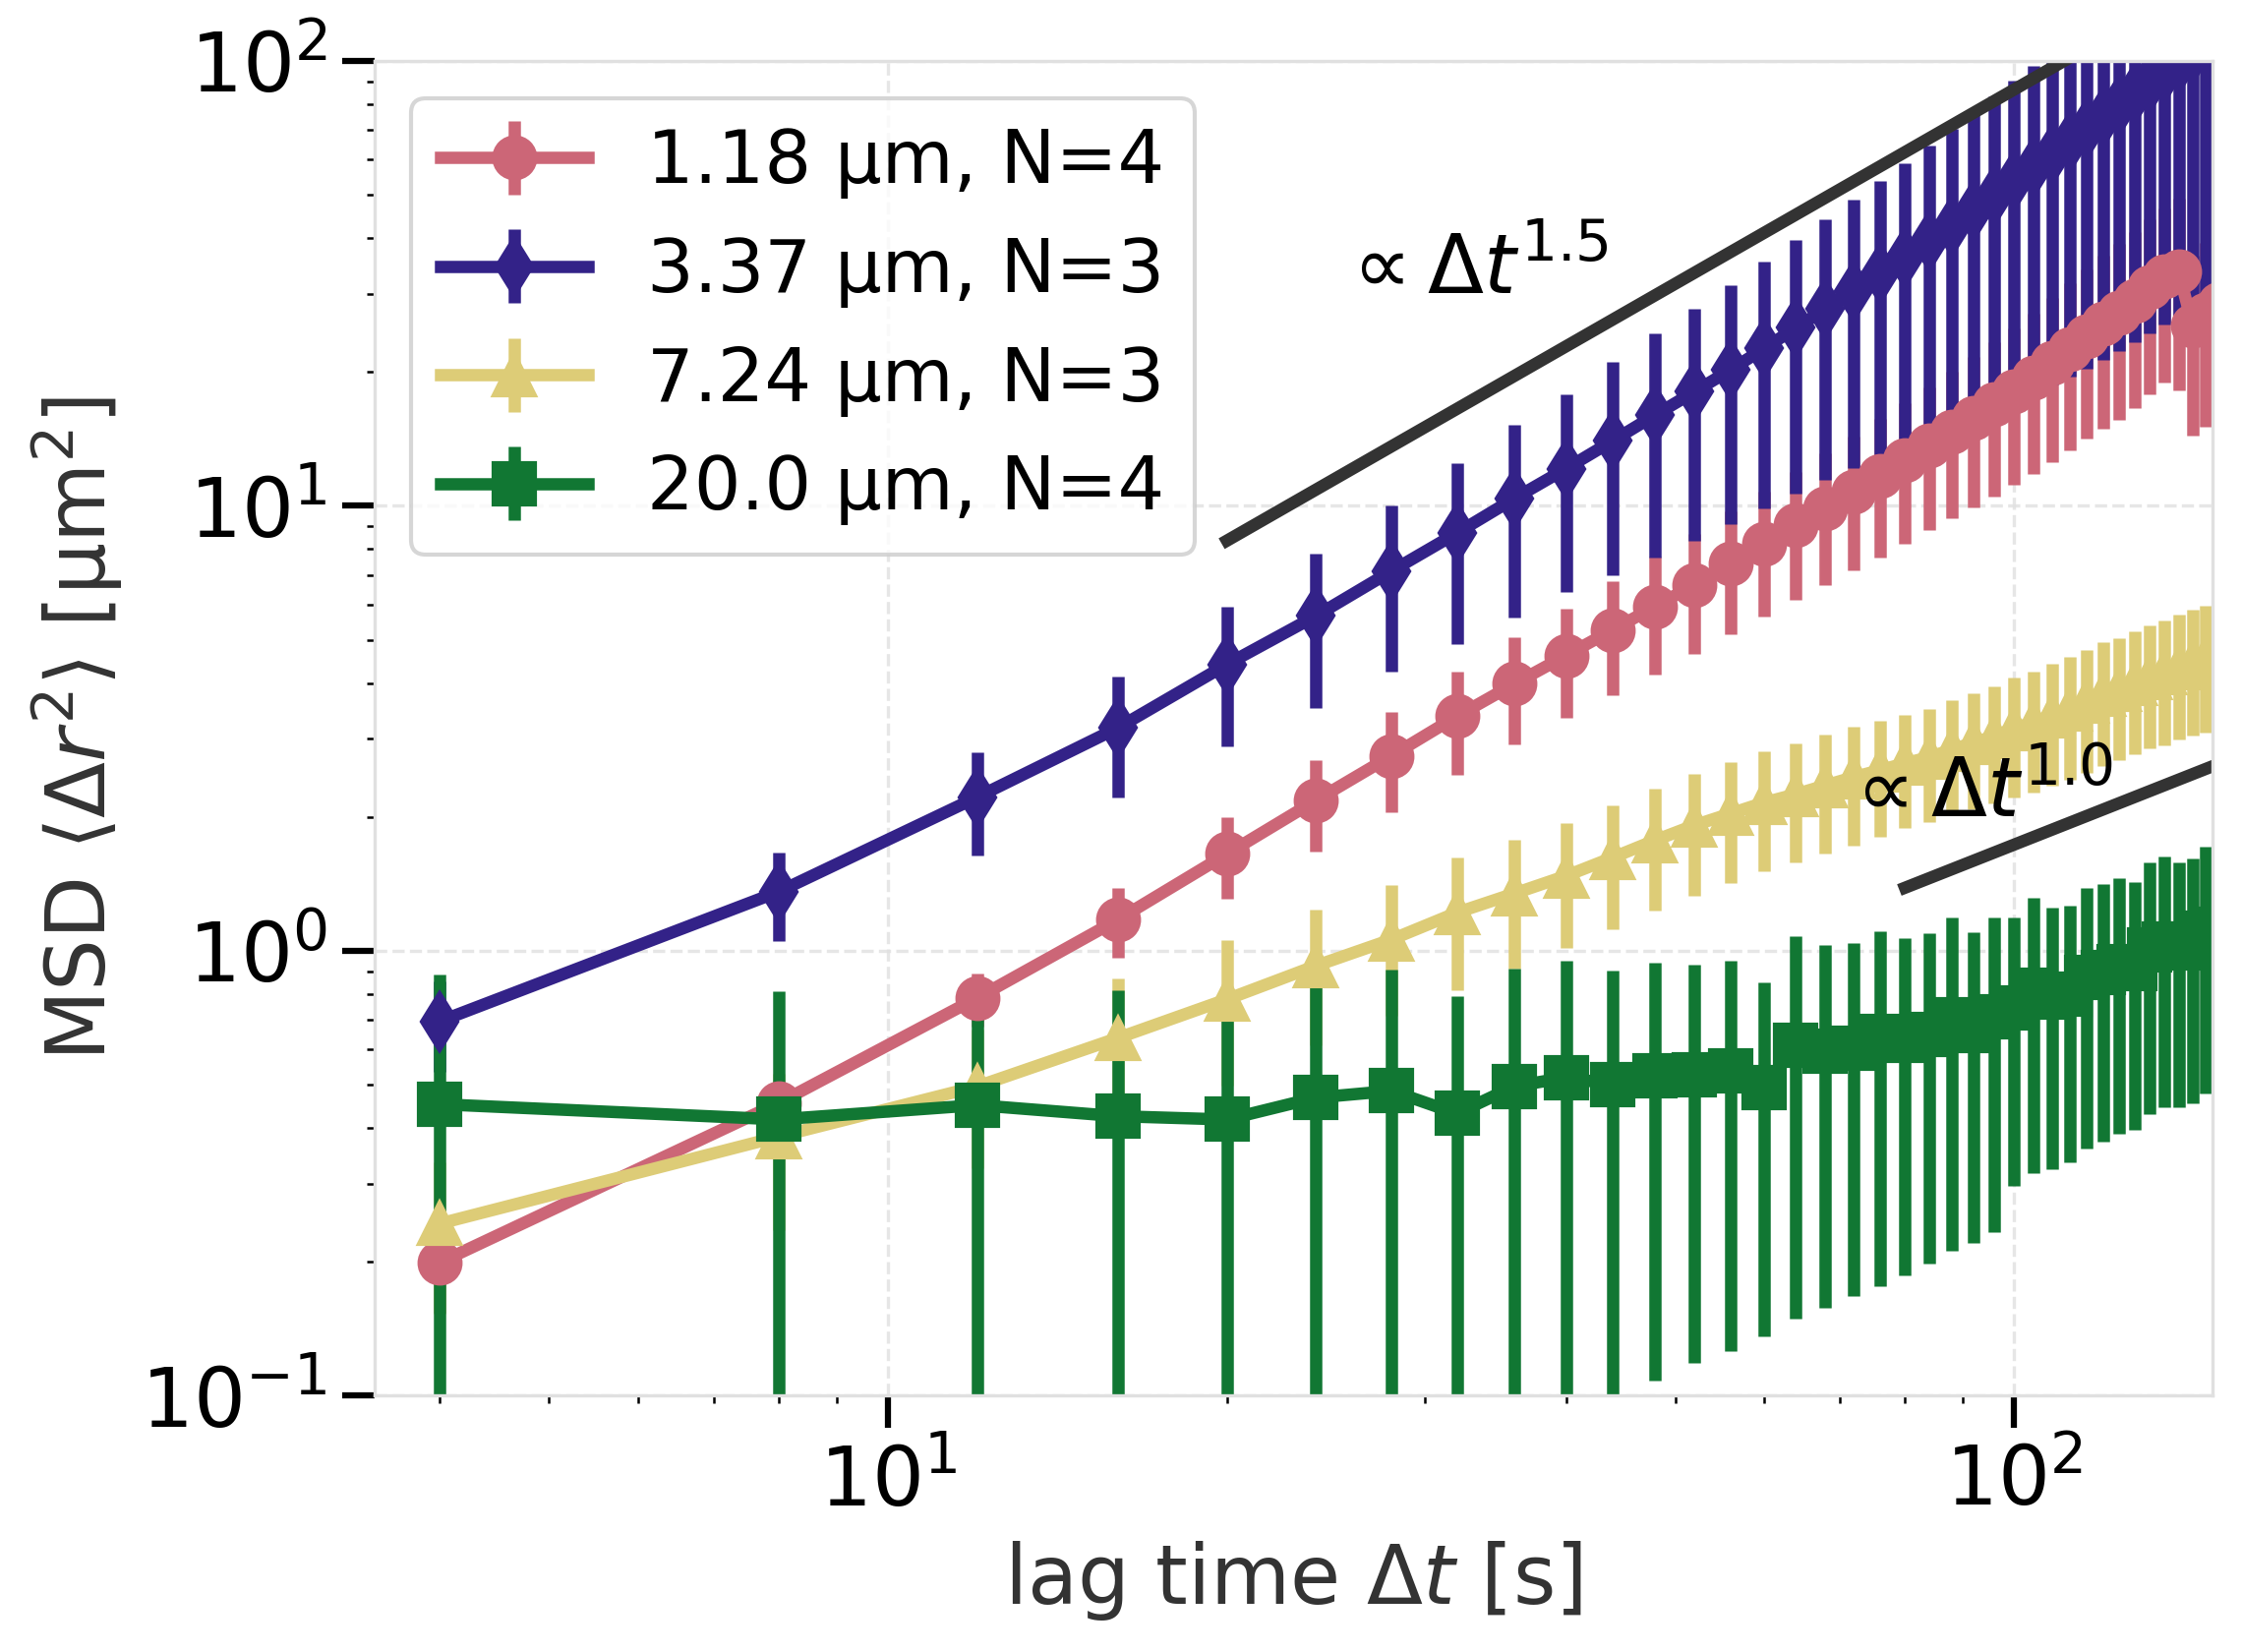

In [2]:
mypass = Path('/mnt/NAS-Ebanaru/sasaki/MTSingleBeads')

def concatMSD(folder, interval_list, scale = 0.11):
    MSD_list = []
    num = 0
    for i in glob.glob(str(Path(folder) / "*" / "*" /"beads_tracks.csv")):
        MSD_df = {"exp":[], "MSD":[]} # Initialize an empty DataFrame to store the results
        IMSD, _ = dpm.get_msd(i, scale, interval_list[num], threshold = 0.0)
        emsd = IMSD.groupby('lag time').mean()['MSD']
        
        MSD_df["MSD"] = emsd
        MSD_df["exp"] = num

        MSD_list.append(pd.DataFrame(MSD_df))

        num +=1
    
    return pd.concat(MSD_list)

I_concat_1um = concatMSD(mypass / "beads1um", [4, 4, 4, 4])
I_concat_3um = concatMSD(mypass / "beads3um", [4, 4, 4])
I_concat_7um = concatMSD(mypass / "beads7um", [4, 4, 4])
I_concat_20um = concatMSD(mypass / "beads20um", [4, 4, 4, 4])

scale = 0.11

alpha = 1
marker_size = 10

min_t = 20
max_t = 144

minimum=min_t/4
maximum=max_t/4

emsd_combined_1um = I_concat_1um.groupby('lag time').mean()['MSD']
emsd_err_combined_1um = I_concat_1um.groupby('lag time').std()['MSD'] / np.sqrt(1+max(I_concat_1um["exp"]))
emsd_combined_3um = I_concat_3um.groupby('lag time').mean()['MSD']
emsd_err_combined_3um = I_concat_3um.groupby('lag time').std()['MSD'] / np.sqrt(1+max(I_concat_3um["exp"]))
emsd_combined_7um = I_concat_7um.groupby('lag time').mean()['MSD']
emsd_err_combined_7um = I_concat_7um.groupby('lag time').std()['MSD'] / np.sqrt(1+max(I_concat_7um["exp"]))
emsd_combined_20um = I_concat_20um.groupby('lag time').mean()['MSD']
emsd_err_combined_20um = I_concat_20um.groupby('lag time').std()['MSD'] / np.sqrt(1+max(I_concat_20um["exp"]))

mask = (emsd_combined_1um.index > minimum) & (emsd_combined_1um.index < maximum)

# take log10 of selected x and y values and convert to numpy arrays
x = np.log10(emsd_combined_1um.index[mask].to_numpy())
y = np.log10(np.float32(emsd_combined_1um[mask].to_numpy()))
 # remove non-finite entries (e.g., log of non-positive values)
finite = np.isfinite(x) & np.isfinite(y)
x = x[finite]
y = y[finite]
# fit
popt, pcov = curve_fit(fm.ln_pl, x, y)

fig, ax = plt.subplots()

#ax.plot(I_concat_1um['lag time'], I_concat_1um['MSD'], color='#333333', alpha =0.1, lw=1, label='Independent particle')

ax.errorbar(emsd_combined_1um.index, emsd_combined_1um, yerr=emsd_err_combined_1um, marker='o', label=f'1.18 \u03bcm, N={1+max(I_concat_1um["exp"])}', alpha = alpha, markersize = marker_size)
ax.errorbar(emsd_combined_3um.index, emsd_combined_3um, yerr=emsd_err_combined_3um, marker='d', label=f'3.37 \u03bcm, N={1+max(I_concat_3um["exp"])}', alpha = alpha, markersize = marker_size)
ax.errorbar(emsd_combined_7um.index, emsd_combined_7um, yerr=emsd_err_combined_7um, marker='^', label=f'7.24 \u03bcm, N={1+max(I_concat_7um["exp"])}', alpha = alpha, markersize = marker_size)  
ax.errorbar(emsd_combined_20um.index, emsd_combined_20um, yerr=emsd_err_combined_20um, marker='s', label=f'20.0 \u03bcm, N={1+max(I_concat_20um["exp"])}', alpha = alpha, markersize = marker_size)

ax.legend()

xrange = [min_t, max_t]

ax.plot(xrange, fm.power_law(xrange, *popt) * 5, label = f'{popt[1]:.2f}$\\times\\Delta t^{{{popt[0]:.2f}}}$', color='#333333')
ax.text(25, 3e1, f'$\propto \Delta t^{{{popt[0]:.1f}}}$')

ax.plot([80,200], fm.power_law([80,200], 1 ,popt[1]*1e-1) * 8, label = f'{popt[1]:.2f}$\\times\\Delta t^{{{popt[0]:.2f}}}$', color='#333333')
ax.text(70, 2, f'$\propto \Delta t^{{{1.0}}}$')

ax.set(
    xlim=(3.5e-0, 150),
    ylim=(1e-1, 1e2),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta t$ [s]',
    ylabel='MSD $\\langle \\Delta r^2 \\rangle$ [\u03bcm$^2$]'
    )


fig.savefig(mypass / "figure" / "MSD.png", bbox_inches = 'tight')
fig.savefig(mypass / "figure" / "MSD.pdf", bbox_inches = 'tight')